<a href="https://colab.research.google.com/github/azrapatvi/dl-practice/blob/main/6_admission_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mukeshmanral/graduates-admission-prediction")

print("Path to dataset files:", path)

100%|██████████| 4.25k/4.25k [00:00<00:00, 7.38MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mukeshmanral/graduates-admission-prediction/versions/1


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [3]:
df=pd.read_csv(os.path.join(path,'admission_data.csv'))

In [4]:
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.columns=df.columns.str.lower().str.strip()

In [7]:
df.columns

Index(['gre score', 'toefl score', 'university rating', 'sop', 'lor', 'cgpa',
       'research', 'chance of admit'],
      dtype='object')

In [8]:
X=df.drop('chance of admit',axis=1)
y=df['chance of admit']

In [9]:
y

,chance of admit
0,0.92
1,0.76
2,0.72
3,0.80
4,0.65
...,...
495,0.87
496,0.96
497,0.93
498,0.73


In [10]:
X

,gre score,toefl score,university rating,sop,lor,cgpa,research
0,337,118,4,4.5,4.5,9.65,1
1,324,107,4,4.0,4.5,8.87,1
2,316,104,3,3.0,3.5,8.00,1
3,322,110,3,3.5,2.5,8.67,1
4,314,103,2,2.0,3.0,8.21,0
...,...,...,...,...,...,...,...
495,332,108,5,4.5,4.0,9.02,1
496,337,117,5,5.0,5.0,9.87,1
497,330,120,5,4.5,5.0,9.56,1
498,312,103,4,4.0,5.0,8.43,0


In [11]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()

In [13]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [14]:
X_train_scaled

array([[0.62      , 0.67857143, 0.5       , ..., 0.71428571, 0.65064103,
        1.        ],
       [0.52      , 0.67857143, 0.75      , ..., 1.        , 0.55769231,
        0.        ],
       [0.26      , 0.35714286, 0.5       , ..., 0.42857143, 0.54487179,
        0.        ],
       ...,
       [0.24      , 0.25      , 0.        , ..., 0.14285714, 0.14423077,
        0.        ],
       [0.38      , 0.46428571, 0.25      , ..., 0.71428571, 0.28205128,
        0.        ],
       [0.48      , 0.5       , 0.25      , ..., 0.57142857, 0.46474359,
        0.        ]])

In [15]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

model=Sequential([
    Dense(16,input_dim=X_train.shape[1],activation='relu'),
    Dense(8,activation='relu'),
    Dense(1,activation='linear'),
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273 (1.07 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    validation_split=0.2,
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.4638 - mae: 0.6492 - val_loss: 0.3896 - val_mae: 0.6044
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2703 - mae: 0.4940 - val_loss: 0.2089 - val_mae: 0.4432
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1388 - mae: 0.3511 - val_loss: 0.0918 - val_mae: 0.2911
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0600 - mae: 0.2241 - val_loss: 0.0327 - val_mae: 0.1613
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0242 - mae: 0.1298 - val_loss: 0.0138 - val_mae: 0.0904
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0143 - mae: 0.0966 - val_loss: 0.0131 - val_mae: 0.0948
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0140 - mae: 0.0950 - val_loss: 0.0138 - val_mae: 0.0998
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0136 - mae: 0.0939 - val_loss: 0.0126 - val_mae: 0.0940
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0127 - mae:

In [20]:
loss,mae=model.evaluate(X_test_scaled,y_test)

print(f"loss:{loss}")
print(f"accuracy:{mae}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0063 - mae: 0.0628
loss:0.006277752108871937
accuracy:0.06282689422369003


In [22]:
history.history

{'loss': [0.46381229162216187,
  0.27034181356430054,
  0.13878706097602844,
  0.05998656153678894,
  0.024197792634367943,
  0.01434263028204441,
  0.01399137545377016,
  0.013569402508437634,
  0.012706826440989971,
  0.012083356268703938,
  0.011674092151224613,
  0.011314054019749165,
  0.011012041941285133,
  0.010749699547886848,
  0.010498052462935448,
  0.010295556858181953,
  0.010104534216225147,
  0.009891772642731667,
  0.009712494909763336,
  0.009551094844937325,
  0.009380947798490524,
  0.009229808114469051,
  0.009085148572921753,
  0.008930953219532967,
  0.008800804615020752,
  0.008639341220259666,
  0.008514469489455223,
  0.008362422697246075,
  0.00821064505726099,
  0.00808868370950222,
  0.007948115468025208,
  0.007807905785739422,
  0.00769417081028223,
  0.007536817342042923,
  0.007394253276288509,
  0.007248629815876484,
  0.007163375616073608,
  0.007021955214440823,
  0.006912072654813528,
  0.006801160983741283,
  0.006703407969325781,
  0.0065907528623

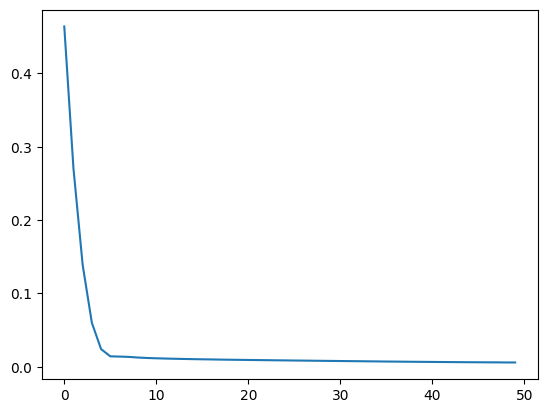

In [24]:
plt.plot(history.history['loss'])
plt.show()

In [25]:
new_data = pd.DataFrame({
    'gre score': [325],
    'toefl score': [112],
    'university rating': [4],
    'sop': [4.0],
    'lor': [4.5],
    'cgpa': [9.10],
    'research': [1]
})

new_data

,gre score,toefl score,university rating,sop,lor,cgpa,research
0,325,112,4,4.0,4.5,9.1,1


In [26]:
new_data_scaled = scaler.transform(new_data)

In [27]:
prediction = model.predict(new_data_scaled)

print("Predicted Chance of Admit:", prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Predicted Chance of Admit: 0.8566532


In [28]:
model.save("admission_model.keras")